<a href="https://colab.research.google.com/github/maibamrakeshsingh/A-Statistical-Framework-for-A-B-Testing-Based-on-P-Value-Analysis/blob/main/Python%20Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !pip install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1
# - Update a specific package
# !pip install pmdarima -U
# - Update a package to specific version
# !pip install --upgrade pmdarima==2.0.2
# Note: If your environment doesn't support "!pip install", use "!mamba install"
!pip install tqdm pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.7 MB/s eta 0:00:00


In [ ]:
# Install tqdm if not already installed
!pip install tqdm

# Import required libraries
from tqdm import tqdm
import numpy as np
import pandas as pd

# Example: create a DataFrame and process with tqdm
data = np.random.randint(1, 100, size=(100, 3))
df = pd.DataFrame(data, columns=['A', 'B', 'C'])

# Use tqdm to show progress while iterating
results = []
for i in tqdm(range(len(df)), desc="Processing rows"):
    row_sum = df.iloc[i].sum()
    results.append(row_sum)

df['Row_Sum'] = results

print(df.head())

Processing rows: 100%|██████████| 100/100 [00:00<00:00, 15038.74it/s]

    A   B   C  Row_Sum
0  12  39   7       58
1  48  86  78      212
2  23  61  62      146
3  62  78  68      208
4  28  33  34       95


In [ ]:
!pip install skillsnetwork

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.4 MB/s eta 0:00:00


In [ ]:
from tqdm import tqdm
import skillsnetwork
import numpy as np
import pandas as pd
#from itertools import accumulate
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.api as sms
%matplotlib inline
from math import ceil

# You can also use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

sns.set_context('notebook')
sns.set_style('white')

In [ ]:
await skillsnetwork.download_dataset('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-GPXX022OEN/ab_data.csv')
df = pd.read_csv('ab_data.csv')

Saved as 'ab_data.csv'


In [ ]:
df.sample(5)

,user_id,timestamp,group,landing_page,converted
169660,762620,2017-01-16 23:46:21.049703,treatment,new_page,1
103298,760047,2017-01-17 18:45:17.294376,control,old_page,1
194975,852755,2017-01-10 01:52:51.483030,treatment,new_page,0
157490,658412,2017-01-13 01:33:52.372314,control,old_page,1
164526,818905,2017-01-07 21:29:45.741528,control,old_page,1


In [ ]:
df['version'] = np.where(df['landing_page'] == 'new_page', 'dark_mode', 'light_mode')
df.head(5)

,user_id,timestamp,group,landing_page,converted,version
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,light_mode
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,light_mode
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,dark_mode
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,dark_mode
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,light_mode


In [ ]:
df['group'].value_counts()

,count
group,
treatment,147276
control,147202


In [ ]:
df['landing_page'].value_counts()

,count
landing_page,
old_page,147239
new_page,147239


In [ ]:
# filter the data based off of the version (dark or light mode)
old_conversion = df[df['version'] == 'light_mode']
new_conversion = df[df['version'] == 'dark_mode']

# get the conversion rates
light_converted = old_conversion['converted'].mean()
dark_converted = new_conversion['converted'].mean()

# print the results
print("The conversion rate in the group using light mode is: %.2f%%" % (100 * light_converted))
print("The conversion rate in the group using dark mode is: %.2f%%" % (100 * dark_converted))

The conversion rate in the group using light mode is: 12.05%
The conversion rate in the group using dark mode is: 11.88%


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
 5   version       294478 non-null  object
dtypes: int64(2), object(4)
memory usage: 13.5+ MB


In [ ]:
# check if some users appear multiple times
user_sessions = df['user_id'].value_counts()

multiple_times_user = user_sessions[user_sessions > 1].count()

multiple_times_user

np.int64(3894)

In [ ]:
dr = user_sessions[user_sessions > 1].index
df = df[~df['user_id'].isin(dr)]

df.head(5)

,user_id,timestamp,group,landing_page,converted,version
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,light_mode
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,light_mode
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,dark_mode
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,dark_mode
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,light_mode


In [ ]:
df.shape[0]

286690

In [ ]:
effect_size = sms.proportion_effectsize(0.13, 0.15)

sample_size = sms.NormalIndPower().solve_power(
    effect_size,
    power = 0.8,
    alpha = 0.05,
    ratio = 1
)

sample_size = ceil(sample_size)

sample_size

4720

In [ ]:
# The treatment and control samples
trt_sample = df[df['group']=='treatment'].sample(n=sample_size, random_state=888)

con_sample = df[df['group'] == 'control'].sample(n=sample_size, random_state=0)

# Combining into one dataframe and resetting the indices
df = pd.concat([con_sample, trt_sample], axis=0)
df.reset_index(drop=True, inplace=True)

df.sample(5)

,user_id,timestamp,group,landing_page,converted,version
9194,642840,2017-01-10 05:02:55.645164,treatment,new_page,0,dark_mode
5231,671178,2017-01-12 05:07:23.693093,treatment,new_page,0,dark_mode
5541,896493,2017-01-09 15:51:52.057675,treatment,new_page,0,dark_mode
6424,847954,2017-01-14 03:23:56.115822,treatment,new_page,0,dark_mode
6075,797686,2017-01-22 02:57:22.510208,treatment,new_page,0,dark_mode


In [ ]:
df.groupby(['group','version']).agg({'converted': 'mean'})

,,converted
group,version,
control,light_mode,0.111017
treatment,dark_mode,0.125000


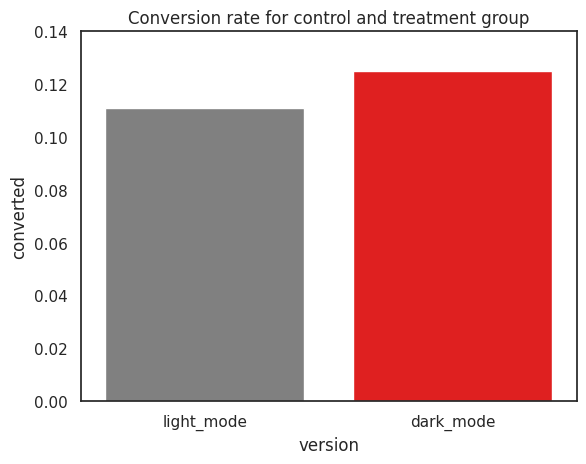

In [ ]:
sns.barplot(x = df['version'], y = df['converted'], palette = ['gray', 'red'], ci = False)
plt.ylim(0, 0.14)
plt.title('Conversion rate for control and treatment group')
plt.show()

In [ ]:
conv_cont = df[df['group'] =='control']['converted']

conv_trt = df[df['group'] =='treatment']['converted']

n_cont = conv_cont.count()

n_trt = conv_trt.count()

num_converted = [conv_cont.sum(), conv_trt.sum()]

nobs = [n_cont, n_trt]

# p-value?
z_stat, pval = sms.proportions_ztest(num_converted, nobs=nobs)

pval

np.float64(0.03524195278525257)

In [ ]:
# Downloading the dataset
await skillsnetwork.download_dataset('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IND-GPXX0K4XEN/marketing_AB.csv')
marketing = pd.read_csv('marketing_AB.csv')
marketing.sample(5)

Saved as 'marketing_AB.csv'


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
205407,205407,1491301,ad,False,70,Wednesday,11
440562,440562,1602709,ad,False,1,Saturday,23
411328,411328,1182606,ad,False,7,Sunday,17
352901,352901,1221569,ad,False,40,Tuesday,9
277661,277661,1593269,ad,False,41,Wednesday,15


In [ ]:
import pandas as pd

# ✅ Safely drop the column if it exists
if 'Unnamed: 0' in marketing.columns:
    marketing = marketing.drop('Unnamed: 0', axis=1)

# ✅ Check if some users appear multiple times
user_sess = marketing['user id'].value_counts()

# Count how many users appear more than once
dup_users = (user_sess > 1).sum()

print("Number of duplicate users:", dup_users)

# ✅ Preview cleaned DataFrame
print(marketing.head())

Number of duplicate users: 0
   user id test group  converted  total ads most ads day  most ads hour
0   903088        psa      False          8       Friday             10
1   904967        psa      False         16     Saturday             19
2   906270        psa       True        204       Monday             14
3   901402        psa      False          2       Friday             15
4   916840        psa      False         38       Friday             16


In [ ]:
effect = sms.proportion_effectsize(0.1, 0.15)

sample_size = sms.NormalIndPower().solve_power(
    effect,
    power = 0.8,
    alpha = 0.05,
    ratio = 1
)

sample_size = ceil(sample_size)

sample_size

681

In [ ]:
# The treatment and control samples
trt = marketing[marketing['test group'] == 'ad'].sample(n=sample_size, random_state=12)

con = marketing[marketing['test group'] == 'psa'].sample(n=sample_size, random_state=12)

# Combining into one dataframe and resetting the indices
marketing = pd.concat([con, trt], axis=0)
marketing.reset_index(drop=True, inplace=True)

marketing.head(5)

,user id,test group,converted,total ads,most ads day,most ads hour
0,903088,psa,False,8,Friday,10
1,904967,psa,False,16,Saturday,19
2,906270,psa,True,204,Monday,14
3,901402,psa,False,2,Friday,15
4,916840,psa,False,38,Friday,16


In [ ]:
# Import the function
from statsmodels.stats import proportion as sms

# Run the proportions z-test
z_stat, p_val = sms.proportions_ztest(count=num_converted, nobs=nobs)

# The function returns two values:
#   z_stat → the z-statistics score
#   p_val  → the p-value
print("Z-statistic:", z_stat)
print("P-value:", p_val)

Z-statistic: -0.19438647254232758
P-value: 0.8458732812504042


In [ ]:
converted_con = marketing[marketing['test group'] == 'ad']['converted']

converted_trt = marketing[marketing['test group'] == 'psa']['converted']

n_control = converted_con.count()

n_treatment = converted_trt.count()

num_converted = [converted_con.sum(), converted_trt.sum()]

nobs = [n_control, n_treatment]

# p-value?
z_stat, pval = sms.proportions_ztest(num_converted, nobs=nobs)

pval

np.float64(0.8458732812504042)